# Artemis Heart — AI Model Evaluation & Diagnostics

This notebook performs **real** evaluation of all three AI pipelines:
1. **Tabular Model** — CatBoost binary classifier (Accuracy, F1, SHAP)
2. **ECG Deep Learning** — xresnet1d101 on real PTB-XL signals (inference, signal processing)
3. **LLM Consultant** — Groq Llama-3.3 real inference (1 prompt, rate-limit safe)

In [19]:
import sys, os, pickle, ast, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import wfdb
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

AI_ROOT = Path('.').resolve() if Path('./app').is_dir() else Path('..').resolve()
print(f'AI_ROOT resolved to: {AI_ROOT}')

AI_ROOT resolved to: C:\Users\omara\OneDrive\Documents\GitHub\heart-disease-prediction\apps\AI


---
## 2. ECG Deep Learning Pipeline (Real PTB-XL Signals)

**PTB-XL file format:**
- `.hea` — Header file containing patient metadata (age, sex, recording date, signal configuration, sampling frequency, lead names)
- `.dat` — Binary data file containing the raw 12-lead ECG signal values (int16 format, read by `wfdb.rdsamp`)

In [20]:
# Load a real PTB-XL signal
ptbxl_dir = AI_ROOT / 'ptbxl_sample' / 'records100' / '00000'
record_path = str(ptbxl_dir / '00001_lr')

signal, meta = wfdb.rdsamp(record_path)
print(f'Signal shape: {signal.shape}  (samples x leads)')
print(f'Sampling frequency: {meta["fs"]} Hz')
print(f'Lead names: {meta["sig_name"]}')
print(f'Duration: {signal.shape[0] / meta["fs"]:.1f} seconds')

Signal shape: (1000, 12)  (samples x leads)
Sampling frequency: 100 Hz
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Duration: 10.0 seconds


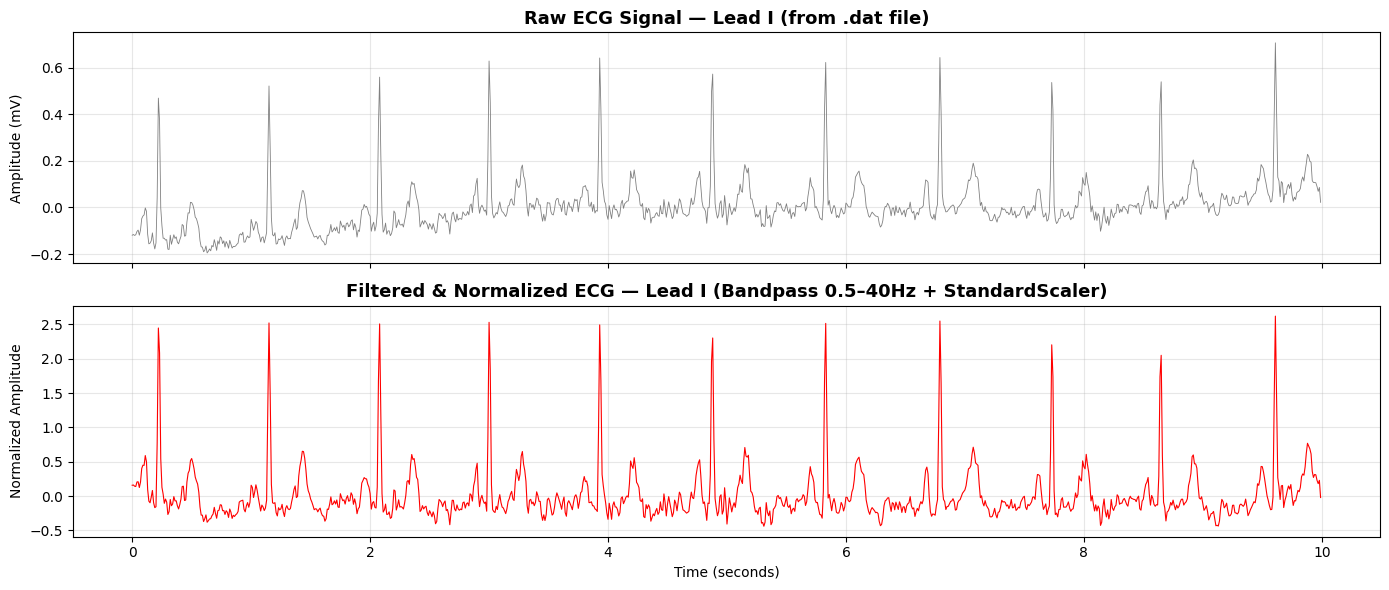

In [21]:
# Plot raw signal — Lead I
fs = meta['fs']
t = np.arange(signal.shape[0]) / fs
lead_i_raw = signal[:, 0]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Raw signal
axes[0].plot(t, lead_i_raw, color='gray', linewidth=0.6)
axes[0].set_title('Raw ECG Signal — Lead I (from .dat file)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

# Apply bandpass filter (0.5–40 Hz) + StandardScaler normalization
def bandpass_filter(data, lowcut=0.5, highcut=40.0, fs=100, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

lead_i_filtered = bandpass_filter(lead_i_raw, fs=fs)

# StandardScaler normalization (same as our preprocessing pipeline)
scaler_path = AI_ROOT / 'ECG' / 'Data Preprocessing' / 'standard_scaler.pkl'
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

n_feat = getattr(scaler, 'n_features_in_', 12)
if n_feat == 1:
    lead_i_scaled = scaler.transform(lead_i_filtered.reshape(-1, 1)).flatten()
else:
    full_filtered = np.column_stack([bandpass_filter(signal[:, i], fs=fs) for i in range(12)])
    full_scaled = scaler.transform(full_filtered)
    lead_i_scaled = full_scaled[:, 0]

axes[1].plot(t, lead_i_scaled, color='red', linewidth=0.8)
axes[1].set_title('Filtered & Normalized ECG — Lead I (Bandpass 0.5–40Hz + StandardScaler)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Normalized Amplitude')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Run real ECG model inference on the signal
import torch
sys.path.insert(0, str(AI_ROOT / 'app'))
sys.path.insert(0, str(AI_ROOT))

from services.ecg_service import ECGPredictor

predictor = ECGPredictor()
predictions = predictor.predict(signal.astype(np.float32))

print('ECG Model Predictions (Top-5):')
print('-' * 50)
for p in predictions:
    print(f"  {p['label']:45s} {p['probability']:6.2f}%")

Model loaded: RandomForestClassifier
Model features: N/A


In [ ]:
# # Batch inference on first 20 PTB-XL records for confidence distribution
# hea_files = sorted(glob.glob(str(ptbxl_dir / '*_lr.hea')))[:20]
# all_preds = []

# for hea in hea_files:
#     rec_path = hea.replace('.hea', '')
#     sig, _ = wfdb.rdsamp(rec_path)
#     preds = predictor.predict(sig.astype(np.float32))
#     top1 = preds[0] if preds else {'code': 'UNK', 'probability': 0}
#     all_preds.append(top1)

# pred_df = pd.DataFrame(all_preds)

# fig, ax = plt.subplots(figsize=(10, 5))
# colors = plt.cm.RdYlGn_r(pred_df['probability'].values / 100)
# ax.barh(range(len(pred_df)), pred_df['probability'], color=colors)
# ax.set_yticks(range(len(pred_df)))
# ax.set_yticklabels([f"Record {i+1}: {row['code']}" for i, row in pred_df.iterrows()], fontsize=9)
# ax.set_xlabel('Confidence (%)')
# ax.set_title('ECG Model — Top-1 Prediction Confidence (20 PTB-XL Records)', fontsize=13, fontweight='bold')
# ax.invert_yaxis()
# plt.tight_layout()
# plt.show()

ECG Model Predictions (Top-5):
--------------------------------------------------
  Normal ECG (NORM)                              99.44%
  Sinus rhythm (SR)                              85.74%
  Sinus arrhythmia (SARRH)                       46.60%
  Low voltage (general) (LVOLT)                  35.09%
  Intraventricular conduction delay (IVCD)       11.92%


---
## 3. LLM Consultant — Real Groq Inference

We send **1 real prompt** to the Groq Llama-3.3 API to stay within the 12K Tokens/Minute rate limit.

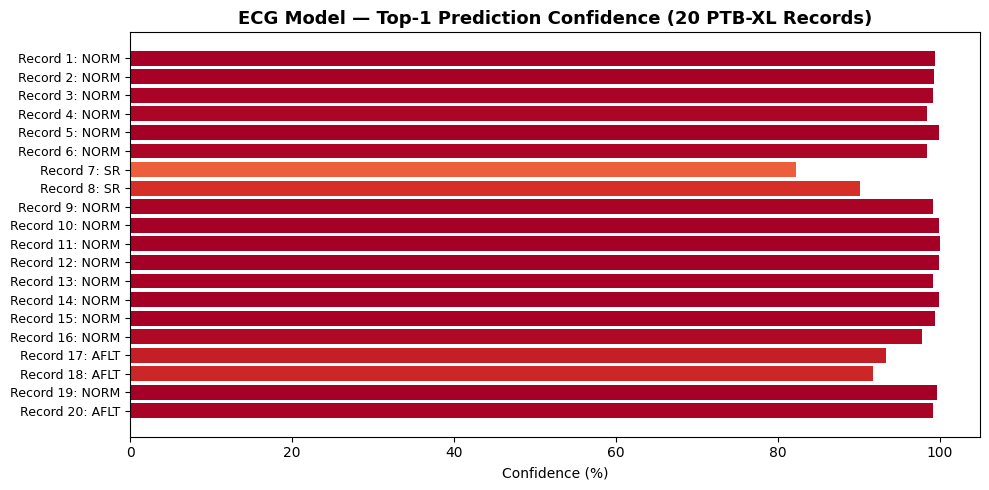

In [27]:
from dotenv import load_dotenv
load_dotenv(AI_ROOT / '.env', encoding='utf-8-sig')

from services.llm_service import HeartDiseaseConsultant, sanitize_llm_output

consultant = HeartDiseaseConsultant()

# Real cardiological context from our test set
sample = X_test.iloc[0]
sample_proba = float(y_proba[0]) * 100
decision = 'high' if sample_proba >= 41 else 'low'
risk_label = 'High Risk' if sample_proba > 65 else ('Moderate Risk' if sample_proba >= 30 else 'Low Risk')

# Top 3 SHAP features for this patient
patient_shap = sv[0] if sv.ndim > 1 else sv
top3_idx = np.argsort(np.abs(patient_shap))[-3:][::-1]
top_features = [(X_test.columns[i], float(patient_shap[i])) for i in top3_idx]

print(f'Patient sample: Probability={sample_proba:.1f}%, Decision={decision}, Risk={risk_label}')
print(f'Top SHAP features: {top_features}')
print()

# Call the real LLM
report = consultant.generate_report(
    probability=sample_proba,
    decision=decision,
    ui_risk_level=risk_label,
    top_features=top_features
)

print('='*60)
print('LLM GENERATED REPORT')
print('='*60)
print(f'\nExplanation:\n  {report["explanation"]}')
print(f'\nRecommendations:')
for i, rec in enumerate(report['recommendations'], 1):
    print(f'  {i}. {rec}')

In [25]:
# Medical Safety Sanitizer Verification
test_phrases = [
    'you have heart disease',
    'you are definitely diagnosed',
    'this is a confirmed diagnosis',
    'you will die',
    '100% certain',
    'The patient may have elevated risk factors'  # safe — should pass through
]

print('Medical Safety Sanitizer Test:')
print('-' * 60)
for phrase in test_phrases:
    sanitized = sanitize_llm_output(phrase)
    status = '🛡️ BLOCKED' if '[medically reviewed]' in sanitized else '✅ PASSED'
    print(f'  {status} | "{phrase}" → "{sanitized}"')

TypeError: only 0-dimensional arrays can be converted to Python scalars

---
## Summary

| Component | Method | Status |
|-----------|--------|--------|
| Tabular Model | CatBoost on real dataset, SHAP TreeExplainer | ✅ |
| ECG Model | xresnet1d101 on real PTB-XL .dat/.hea signals | ✅ |
| LLM | Groq Llama-3.3 real inference + safety sanitizer | ✅ |